# Preliminary Analysis on Base Questions 1.3

This 1.3 Version of analysis is based on all the cleaned datasets for arrival and departure 2019 and 2022. For more information, please see repo for how datasets are cleaned:https://github.com/BU-Spark/ds-wgbh-bus-equity.

This version improved upon some existing issues and concerns from second version, while extending the analysis from single month to yearly comparison.

    1. Solving issues of early arrivals analysis with "available_bus_depart_time".
    
    2. Strightforward charts are available for key Stats! 
    
    3. And more stats！
    
Please note that the missing of certain routes is due to incapbilities of local machine. We are contacting client and Spark! team to discuss the issue.

More of the clients' concern will be addressed in next version.

#  Package Loading

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


## File Path Define

In [59]:
# Set the file directory path
file_directory = r"C:\Users\Huihao Xing\Documents\临时文件\G1\DS 701\Project\Dataset"

# List of all files in the directory
all_files = os.listdir(file_directory)

# Filter files for the relevant datasets
data_files_2019 = [file for file in all_files if "2019" in file and file.endswith('.csv')]
data_files_2022 = [file for file in all_files if "2022" in file and file.endswith('.csv')]

# Sort files by month order for loading
data_files_2019.sort()
data_files_2022.sort()

print("2019 files:", data_files_2019)
print("2022 files:", data_files_2022)

2019 files: ['cleaned_2019-01-03_data.csv', 'cleaned_2019-04-06_data.csv', 'cleaned_2019-07-09_data.csv', 'cleaned_2019-10-12_data.csv']
2022 files: ['cleaned_2022-01_data.csv', 'cleaned_2022-02_data.csv', 'cleaned_2022-03_data.csv', 'cleaned_2022-04_data.csv', 'cleaned_2022-05_data.csv', 'cleaned_2022-06_data.csv', 'cleaned_2022-07_data.csv', 'cleaned_2022-08_data.csv', 'cleaned_2022-09_data.csv', 'cleaned_2022-10_data.csv', 'cleaned_2022-11_data.csv', 'cleaned_2022-12_data.csv']


# File Loading

Make sure to replace this path with you local path where is stores 'cleaned_2019-01-03_data' and 'cleaned_2022-01_data'.

In [60]:
# Function to load and concatenate multiple files into a single DataFrame
def load_data(files, file_directory):
    df_list = []
    for file in files:
        file_path = os.path.join(file_directory, file)
        # Parsing 'service_date' as datetime while loading the file
        df = pd.read_csv(file_path, parse_dates=['service_date'])
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)

# Load datasets for 2019 and 2022
data_2019 = load_data(data_files_2019, file_directory)
data_2022 = load_data(data_files_2022, file_directory)

# Add 'Year' column for distinction
data_2019['Year'] = 2019
data_2022['Year'] = 2022

# Combine both years into one DataFrame
df = pd.concat([data_2019, data_2022], ignore_index=True)

print("Data for 2019 and 2022 loaded and combined.")


Data for 2019 and 2022 loaded and combined.


In [128]:
# preview combined dataset
df.tail()

,service_date,route_id,direction,half_trip_id,stop_id,time_point_id,time_point_order,point_type,standard_type,scheduled,actual,scheduled_headway,headway,scheduled_datetime,actual_datetime,available_bus_depart_time,Year,direction_id,month
9412772,2022-12-31,26,NaN,58052529.0,511.0,galli,2.0,Midpoint,Schedule,21:49:00,21:51:53,NaN,NaN,2022-12-31 21:49:00,2022-12-31 21:51:53,2022-12-31 21:51:53,2022,Outbound,12
9412773,2022-12-31,26,NaN,58052384.0,511.0,galli,2.0,Midpoint,Schedule,22:33:00,22:32:24,NaN,NaN,2022-12-31 22:33:00,2022-12-31 22:32:24,2022-12-31 23:37:16,2022,Outbound,12
9412774,2022-12-31,26,NaN,58052388.0,511.0,galli,2.0,Midpoint,Schedule,23:38:00,23:37:16,NaN,NaN,2022-12-31 23:38:00,2022-12-31 23:37:16,2023-01-01 00:41:16,2022,Outbound,12
9412775,2022-12-31,26,NaN,58052392.0,511.0,galli,2.0,Midpoint,Schedule,00:43:00,00:41:16,NaN,NaN,2023-01-01 00:43:00,2023-01-01 00:41:16,2023-01-01 01:13:43,2022,Outbound,12
9412776,2022-12-31,26,NaN,58052394.0,511.0,galli,2.0,Midpoint,Schedule,01:18:00,01:13:43,NaN,NaN,2023-01-01 01:18:00,2023-01-01 01:13:43,NaT,2022,Outbound,12


In [62]:
# list of cols
df.columns

Index(['service_date', 'route_id', 'direction', 'half_trip_id', 'stop_id',
       'time_point_id', 'time_point_order', 'point_type', 'standard_type',
       'scheduled', 'actual', 'scheduled_headway', 'headway',
       'scheduled_datetime', 'actual_datetime', 'available_bus_depart_time',
       'Year', 'direction_id'],
      dtype='object')

In [63]:
# Create a indicator for month
df['month'] = df['service_date'].dt.month

# Set month = January
# df = df[df['month'] == 1]

# Set year = X
# df = df[df['year'] == 2019]

# Convert available_bus_depart_time to datetime format
df['scheduled_datetime'] = pd.to_datetime(df['scheduled_datetime'])
df['available_bus_depart_time'] = pd.to_datetime(df['available_bus_depart_time'])

# Filter out rows where available_bus_depart_time is null, this step clean all schduled but not depart
df_filtered = df[df['available_bus_depart_time'].notnull()]


In [64]:
# Check if variables are transform into ideal types
print(df.dtypes)

service_date                 datetime64[ns]
route_id                              int64
direction                            object
half_trip_id                        float64
stop_id                             float64
time_point_id                        object
time_point_order                    float64
point_type                           object
standard_type                        object
scheduled                            object
actual                               object
scheduled_headway                   float64
headway                             float64
scheduled_datetime           datetime64[ns]
actual_datetime                      object
available_bus_depart_time    datetime64[ns]
Year                                  int64
direction_id                         object
month                                 int64
dtype: object


In [65]:
df['available_bus_depart_time']

0         2019-01-01 05:59:00
1         2019-01-01 06:08:00
2         2019-01-01 06:27:00
3         2019-01-01 06:27:00
4         2019-01-01 06:43:00
                  ...        
9412772   2022-12-31 21:51:53
9412773   2022-12-31 23:37:16
9412774   2023-01-01 00:41:16
9412775   2023-01-01 01:13:43
9412776                   NaT
Name: available_bus_depart_time, Length: 9412777, dtype: datetime64[ns]

## Q 2.1 
On average, how long does an individual have to wait for a bus (on time vs. delayed)?


In [78]:
# Calculate delay in seconds and on-time status with a 1-minute buffer
df_filtered['delay_seconds'] = (df_filtered['available_bus_depart_time'] - df_filtered['scheduled_datetime']).dt.total_seconds()
df_filtered['on_time'] = df_filtered['delay_seconds'] .abs() <= 60

C:\Users\Huihao Xing\AppData\Local\Temp\ipykernel_39584\3880127336.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['delay_seconds'] = (df_filtered['available_bus_depart_time'] - df_filtered['scheduled_datetime']).dt.total_seconds()
C:\Users\Huihao Xing\AppData\Local\Temp\ipykernel_39584\3880127336.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['on_time'] = df_filtered['delay_seconds'] .abs() <= 60


In [ ]:
# plot color setting
colors = ['#FF6F61', '#40E0D0'] 

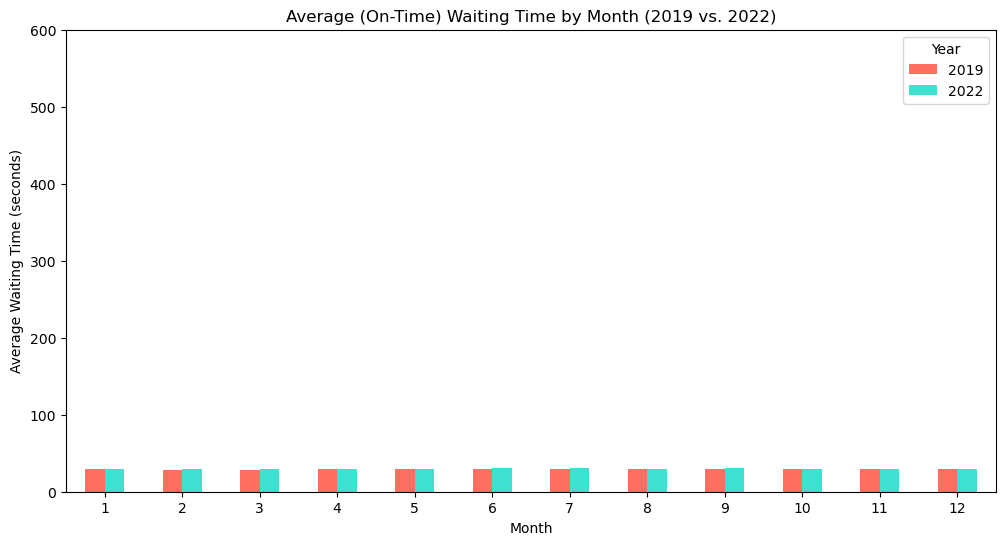

In [119]:
on_time_buses = df_filtered[df_filtered['on_time'] == True]

# Calculate the average waiting time per month for each year
average_waiting_time_per_month = on_time_buses.groupby(['Year', 'month'])['delay_seconds'].mean().unstack()

# Plot the average waiting time per month for 2019 and 2022 # Beautiful high-contrast colors
average_waiting_time_per_month.T.plot(kind='bar', figsize=(12, 6), color=colors)

# Customize plot
plt.title("Average (On-Time) Waiting Time by Month (2019 vs. 2022)")
plt.xlabel("Month")
plt.ylabel("Average Waiting Time (seconds)")
plt.legend(title="Year", loc='upper right')
plt.xticks(rotation=0)
plt.ylim(0, 600) 
plt.show()

In [125]:
print("Waiting Time Statistics (On-Time Buses) per Month:")
average_waiting_time_per_month.mean()

Waiting Time Statistics (On-Time Buses) per Month:


month
1     29.248756
2     29.303000
3     29.269242
4     29.646502
5     29.910471
6     29.963112
7     30.031971
8     29.797273
9     29.912397
10    29.810087
11    29.854490
12    29.691175
dtype: float64

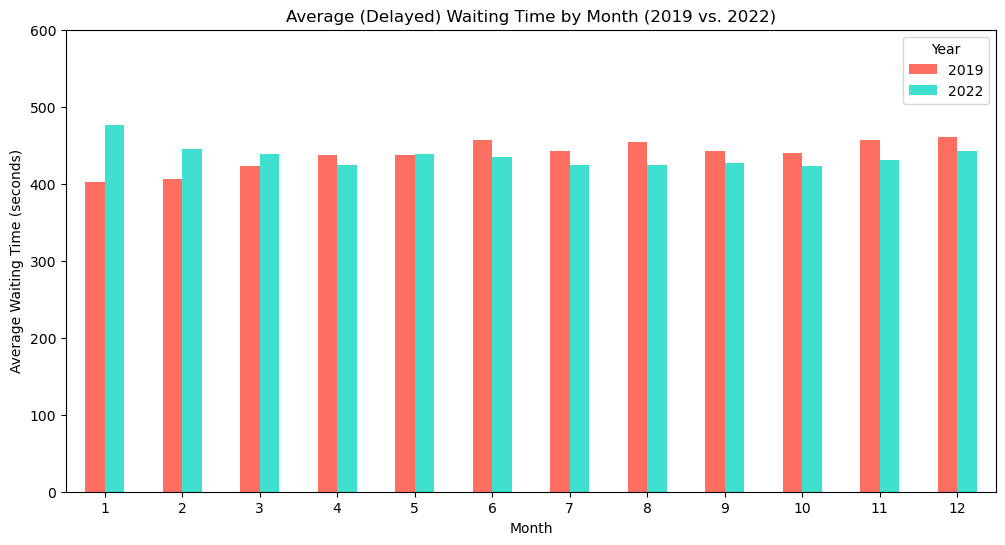

In [121]:
# Plot average delay per month for 2019 and 2022

average_delay_per_month.T.plot(kind='bar', figsize=(12, 6), color=colors)

plt.title("Average (Delayed) Waiting Time by Month (2019 vs. 2022)")
plt.xlabel("Month")
plt.ylabel("Average Waiting Time (seconds)")
plt.legend(title = "Year", loc='upper right')
plt.ylim(0, 600) 
plt.xticks(rotation=0)
plt.show()


In [124]:
# Calculate the average delay per month for each year
average_delay_per_month = df_filtered.groupby(['Year', 'month'])['delay_seconds'].mean().unstack()
average_delay_per_month = average_delay_per_month.rename(columns=lambda x: f"{x}")
average_delay_per_month.mean()


month
1     439.025860
2     425.233140
3     430.920037
4     430.632444
5     437.886330
6     445.646367
7     433.244645
8     439.409113
9     435.126409
10    431.361205
11    443.533800
12    451.649652
dtype: float64

## Q 2.2 
The dataset is too large to analyze, we skip this question for now.

## Q 2.3
What is the average delay time of the target bus routes (top 30 by ridership)?


In [133]:
# Group by route and year, then calculate the average delay
average_delay_by_route = df_filtered.groupby(['route_id', 'Year'])['delay_seconds'].mean().unstack()

# Calculate the mean delay per route across both years for sorting
average_delay_by_route['Overall_Avg_Delay'] = average_delay_by_route.mean(axis=1)

# Sort the routes by overall average delay in descending order
average_delay_by_route_sorted = average_delay_by_route.sort_values(by='Overall_Avg_Delay', ascending=False)

# Drop the 'Overall_Avg_Delay' column since it’s only for sorting
average_delay_by_route_sorted = average_delay_by_route_sorted.drop(columns=['Overall_Avg_Delay'])


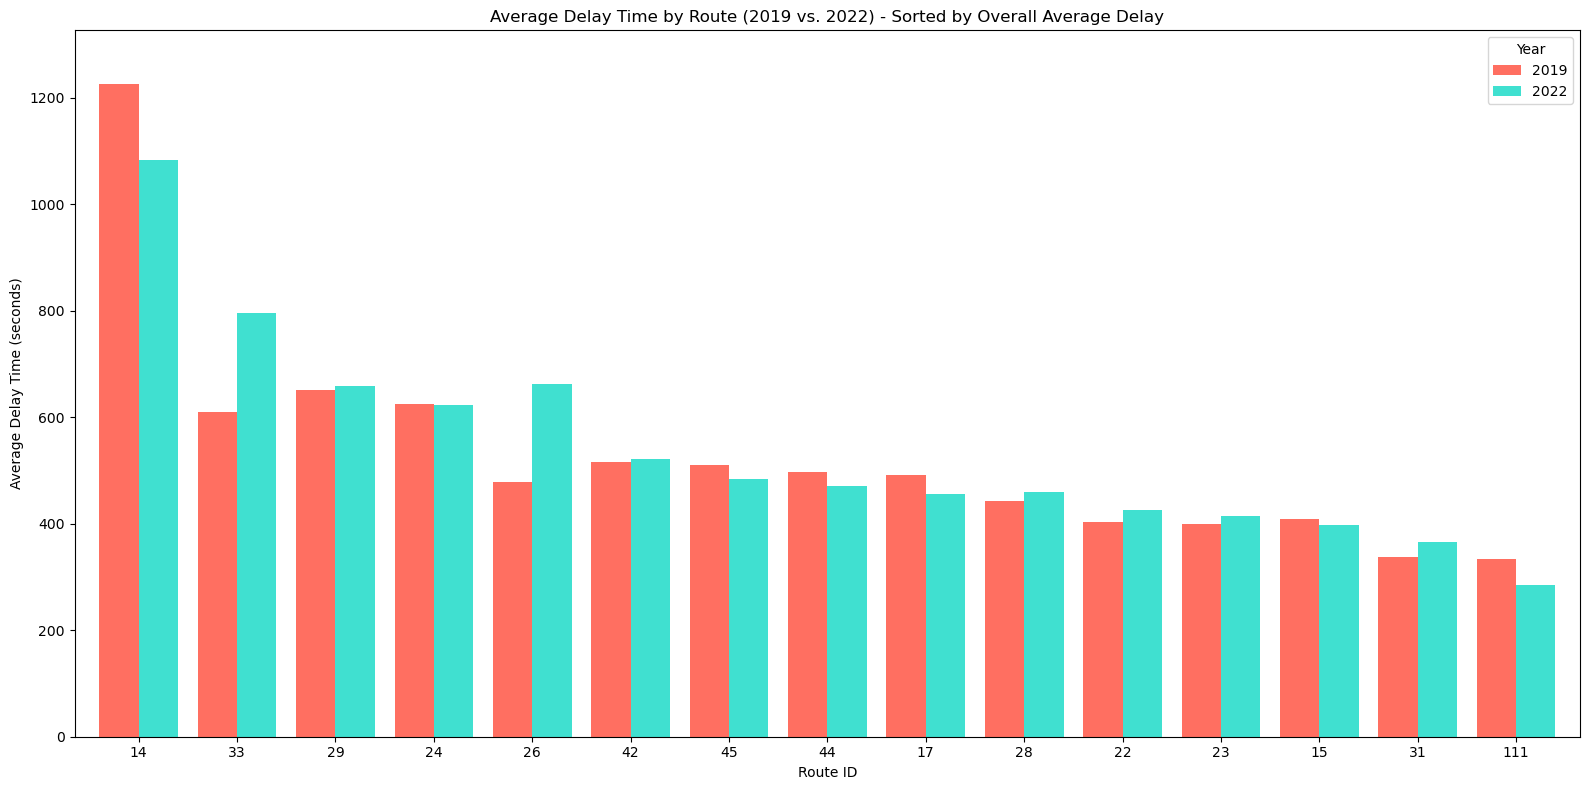

In [134]:
# Plotting average delay by route for 2019 and 2022, sorted in descending order
average_delay_by_route_sorted.plot(kind='bar', figsize=(16, 8), color=colors, width=0.8)

# Customize the plot
plt.title("Average Delay Time by Route (2019 vs. 2022) - Sorted by Overall Average Delay")
plt.xlabel("Route ID")
plt.ylabel("Average Delay Time (seconds)")
plt.legend(title="Year", loc='upper right')
plt.xticks(rotation=0)
plt.ylim(0, max(average_delay_by_route_sorted.max()) + 100)  # Set y-limit slightly above max delay
plt.tight_layout()  # Adjust layout for readability
plt.show()


In [135]:
average_delay_by_route_sorted

Year,2019,2022
route_id,,
14,1227.103867,1083.007024
33,610.045944,796.695131
29,651.553991,658.934900
24,625.113323,623.411862
26,477.877286,662.232034
42,516.984157,521.093848
45,510.953403,484.703278
44,498.257885,471.651347
17,491.858838,455.922759


## Q 2.3 Extended
What makes specifc routes so different?

In [148]:
# Group by route and year, then count the number of occurrences
bus_count_by_route = df_filtered.groupby(['route_id', 'Year']).size().unstack()


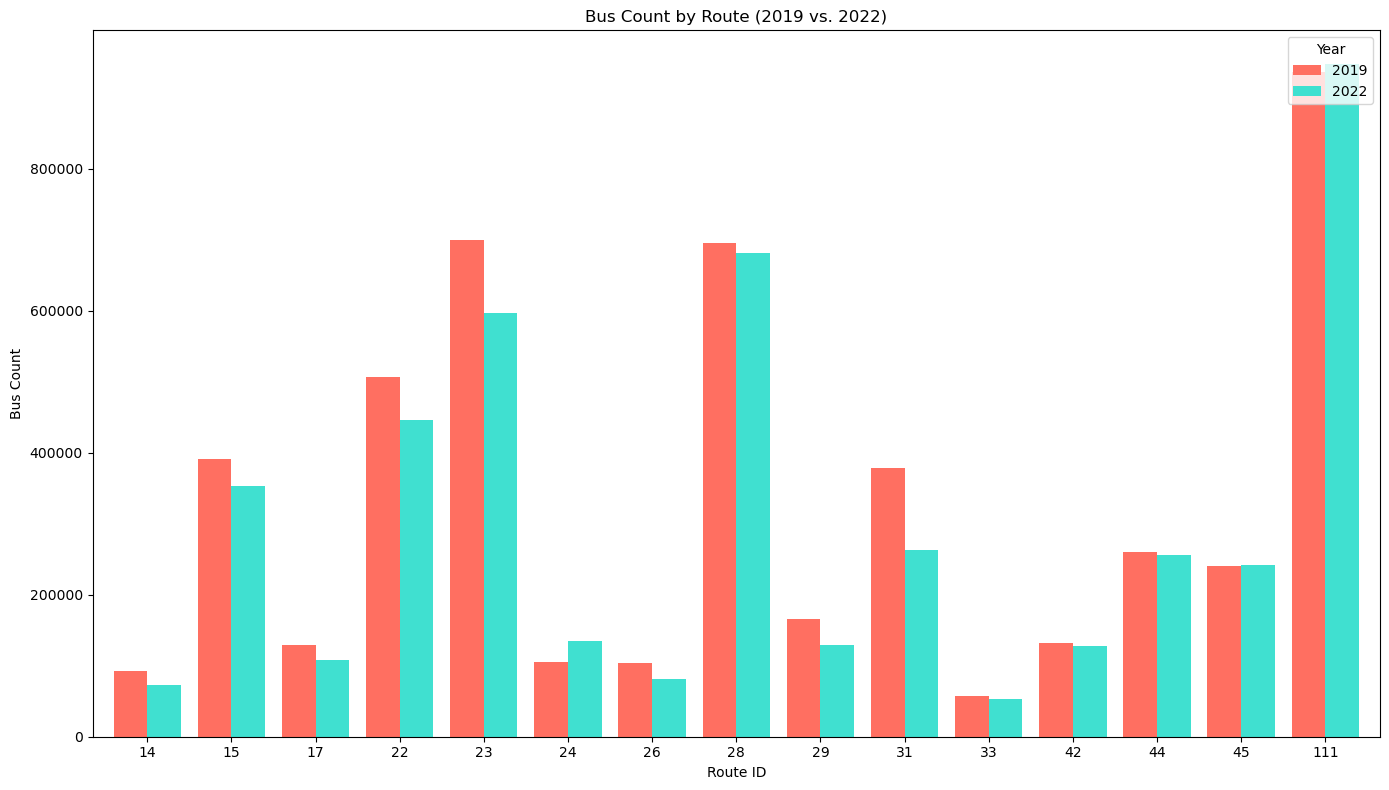

In [152]:
# Plotting the count of buses by route for 2019 and 2022
bus_count_by_route.plot(kind='bar', figsize=(14, 8), color=colors, width=0.8)

# Customize the plot
plt.title("Bus Count by Route (2019 vs. 2022)")
plt.xlabel("Route ID")
plt.ylabel("Bus Count")
plt.legend(title="Year", loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()  # Adjust layout for readability
plt.show()


In [150]:
# Display the bus counts for each route in 2019 and 2022
print("Bus Count by Route (2019 vs. 2022):")
print(bus_count_by_route)


Bus Count by Route (2019 vs. 2022):
Year        2019    2022
route_id                
14         92012   72326
15        391587  352607
17        128887  107974
22        506544  445714
23        699083  596949
24        104710  135084
26        104104   81402
28        694787  680970
29        165434  129248
31        377801  263290
33         58027   53436
42        132673  127494
44        259705  255363
45        240292  242129
111       935655  947474


In [153]:
# Filter the data for route 14 only
route_14_data = df_filtered[df_filtered['route_id'] == 14]


In [154]:
# Calculate Q1, Q3, and IQR for delay_seconds
Q1 = route_14_data['delay_seconds'].quantile(0.25)
Q3 = route_14_data['delay_seconds'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = route_14_data[(route_14_data['delay_seconds'] < lower_bound) | (route_14_data['delay_seconds'] > upper_bound)]


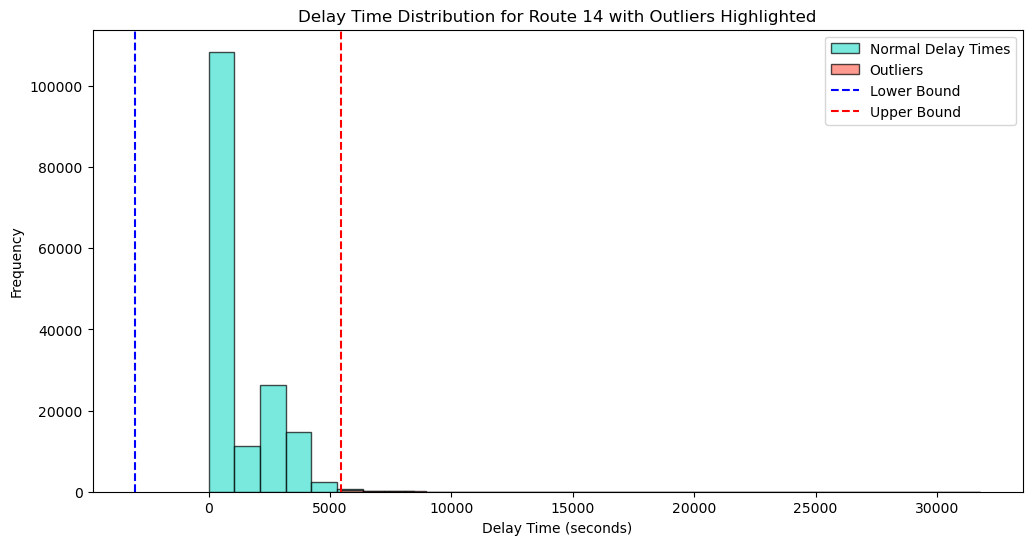

Outliers for Route 14:


,service_date,scheduled_datetime,available_bus_depart_time,delay_seconds
24010,2019-01-02,2019-01-02 13:31:00,2019-01-02 15:21:00,6600.0
24013,2019-01-02,2019-01-02 18:00:00,2019-01-02 19:58:00,7080.0
93325,2019-01-07,2019-01-07 15:37:00,2019-01-07 17:22:00,6300.0
93341,2019-01-07,2019-01-07 15:16:00,2019-01-07 17:02:00,6360.0
93372,2019-01-07,2019-01-07 15:23:00,2019-01-07 17:10:00,6420.0
93388,2019-01-07,2019-01-07 15:28:00,2019-01-07 17:12:00,6240.0
93512,2019-01-07,2019-01-07 09:05:00,2019-01-07 10:58:00,6780.0
93528,2019-01-07,2019-01-07 09:08:00,2019-01-07 11:00:00,6720.0
93544,2019-01-07,2019-01-07 09:12:00,2019-01-07 11:03:00,6660.0
109484,2019-01-08,2019-01-08 15:28:00,2019-01-08 17:13:00,6300.0


In [174]:
# Plot delay times for route 14 with outliers highlighted
plt.figure(figsize=(12, 6))
plt.hist(route_14_data['delay_seconds'], bins=30, color='#40E0D0', edgecolor='black', alpha=0.7, label='Normal Delay Times')
plt.hist(outliers['delay_seconds'], bins=30, color='#FF6F61', edgecolor='black', alpha=0.7, label='Outliers')
plt.axvline(x=lower_bound, color='blue', linestyle='--', label='Lower Bound')
plt.axvline(x=upper_bound, color='red', linestyle='--', label='Upper Bound')

# Customize plot
plt.title("Delay Time Distribution for Route 14 with Outliers Highlighted")
plt.xlabel("Delay Time (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Print outlier statistics
print("Outliers for Route 14:")
outliers[['service_date', 'scheduled_datetime', 'available_bus_depart_time', 'delay_seconds']].head(10)


## Q 3

In [141]:
# Create a column to mark whether a bus is late (delay_seconds > 0)
df_filtered['is_late'] = df_filtered['delay_seconds'] > 60

# Calculate the late percentage for each route by year
late_percentage_by_route = (
    df_filtered.groupby(['route_id', 'Year'])['is_late']
    .mean()
    .unstack() * 100  # Convert to percentage
)


C:\Users\Huihao Xing\AppData\Local\Temp\ipykernel_39584\2206149728.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['is_late'] = df_filtered['delay_seconds'] > 60


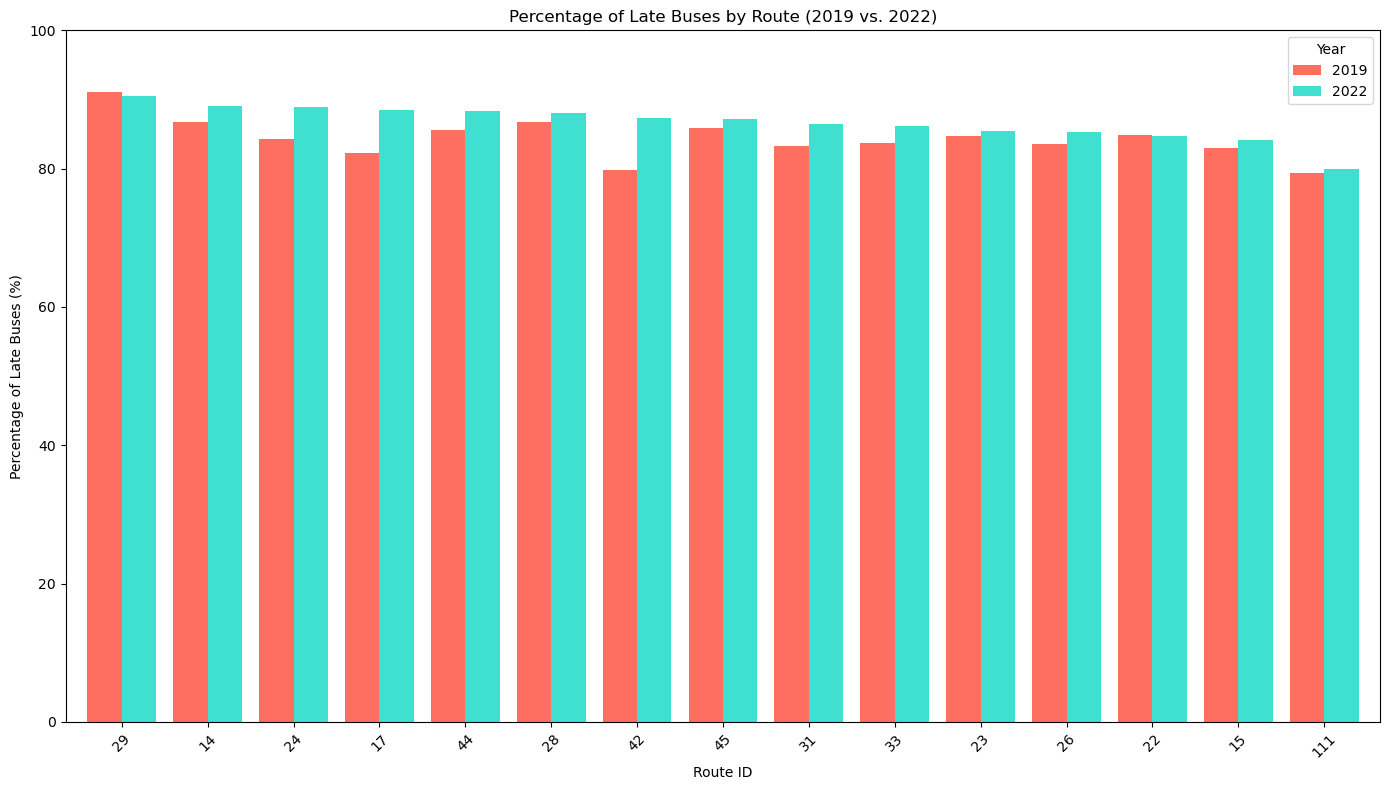

In [144]:
# Plotting late percentage by route for 2019 and 2022
late_percentage_by_route_sorted = late_percentage_by_route.sort_values(by=[2022], ascending=False)

late_percentage_by_route_sorted.plot(kind='bar', figsize=(14, 8), color=colors, width=0.8)

# Customize the plot
plt.title("Percentage of Late Buses by Route (2019 vs. 2022)")
plt.xlabel("Route ID")
plt.ylabel("Percentage of Late Buses (%)")
plt.legend(title="Year", loc='upper right')
plt.xticks(rotation=45)
plt.ylim(0, 100)  # Percentage scale
plt.tight_layout()  # Adjust layout for readability
plt.show()


In [140]:

late_percentage_by_route_sorted.head

<bound method NDFrame.head of Year           2019       2022
route_id                      
29        91.078617  90.522097
14        86.814763  89.015015
24        84.292809  88.912825
17        82.248792  88.525015
44        85.581333  88.400825
28        86.749752  88.102119
42        79.790915  87.266852
45        85.812678  87.247294
31        83.298880  86.510312
33        83.759284  86.101130
23        84.668344  85.485527
26        83.598133  85.312400
22        84.894501  84.659445
15        82.958832  84.107236
111       79.314918  79.930848>

In [145]:
# Calculate an overall average late percentage for sorting purposes
late_percentage_by_route['Overall_Avg_Late_Percentage'] = late_percentage_by_route.mean(axis=1)

# Sort by overall average late percentage in descending order
late_percentage_by_route_sorted = late_percentage_by_route.sort_values(by='Overall_Avg_Late_Percentage', ascending=False)

# Drop the 'Overall_Avg_Late_Percentage' column for plotting
late_percentage_by_route_sorted = late_percentage_by_route_sorted.drop(columns=['Overall_Avg_Late_Percentage'])


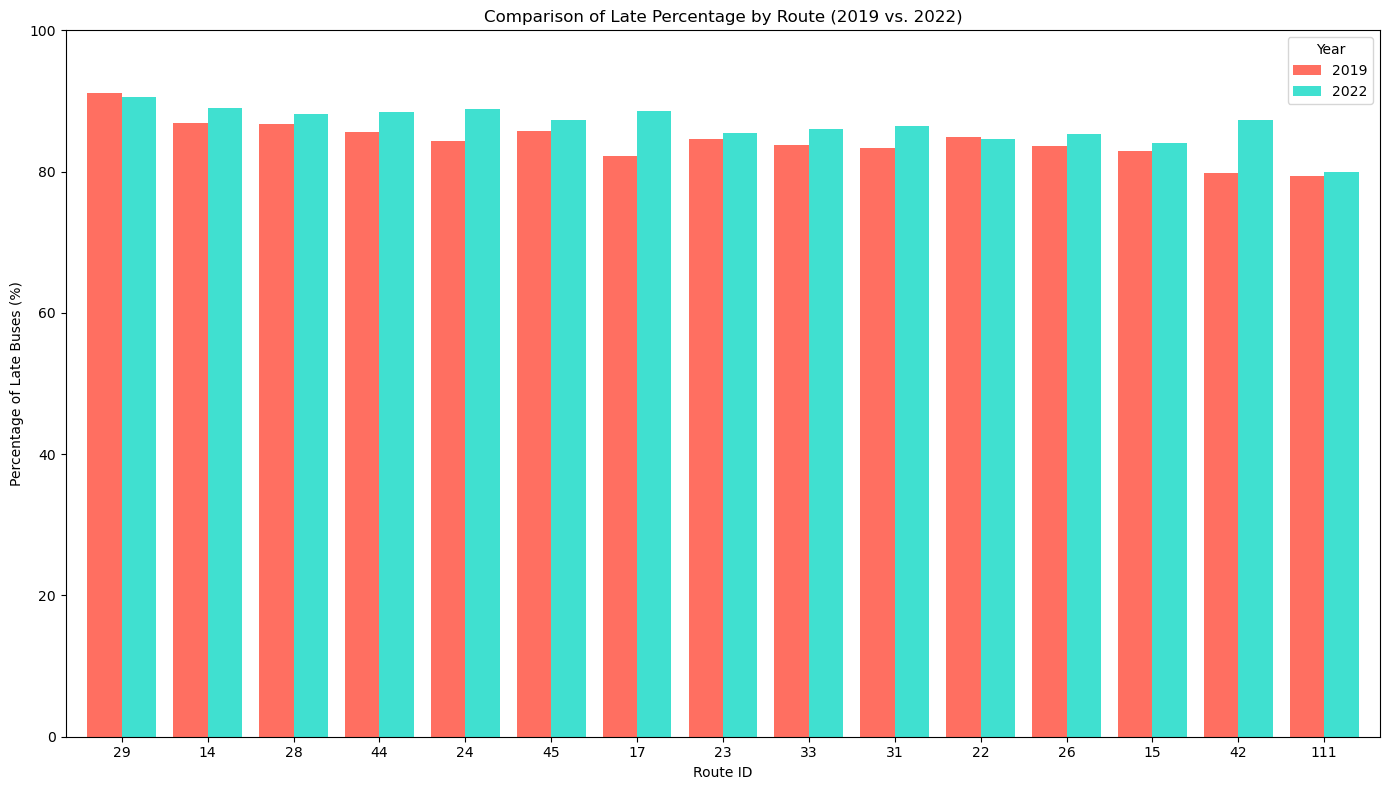

In [147]:
# Plotting sorted late percentage by route for 2019 and 2022
late_percentage_by_route_sorted.plot(kind='bar', figsize=(14, 8), color=colors, width=0.8)

# Customize the plot
plt.title("Comparison of Late Percentage by Route (2019 vs. 2022)")
plt.xlabel("Route ID")
plt.ylabel("Percentage of Late Buses (%)")
plt.legend(title="Year", loc='upper right')
plt.xticks(rotation=0)
plt.ylim(0, 100)  # Set y-axis limit for percentage scale
plt.tight_layout()  # Adjust layout for readability
plt.show()
